## Policy Visualization Features

The visualization shows:
- **Color-coded actions**: Each cell is colored based on the action taken
  - 🔴 Red = Left (←)
  - 🔵 Teal = Down (↓)  
  - 🔵 Blue = Right (→)
  - 🟠 Orange = Up (↑)
- **Arrows**: Direction symbols show the policy action
- **Special cells**:
  - 🟢 Green border = Start state (S)
  - ⬛ Black = Holes (H) - terminal states to avoid
  - 🟡 Gold = Goal (G) - terminal state to reach
- **Value function**: Optional display of state values above each cell
- **Real-time updates**: Policy updates after each iteration

Two visualization modes:
1. **Live updates**: Shows policy changing in real-time (Cell 2)
2. **Side-by-side**: Shows all iterations in a grid for comparison (Cell 4)

policy iteration is when we iteratively do evaluation and improvement steps. During evaluation we follow the policy and find a value function then use that value function to generate a new policy by acting greedyly and then use the new policy to create new value function and keep on doing this till we reach the optimal policy

we'll use the same frozen lake env with slip true

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import numpy as np

def visualize_policy(env, policy, value_function=None, iteration=0, ax=None):
    """
    Visualize the policy as a grid with color-coded actions and arrows.
    
    Args:
        env: Gymnasium FrozenLake environment
        policy: Array of actions for each state
        value_function: Optional array of state values
        iteration: Current iteration number
        ax: Optional matplotlib axis (for updating existing plot)
    """
    # Get environment dimensions
    desc = env.unwrapped.desc  # Map description
    nrow, ncol = desc.shape
    
    # Create figure if no axis provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
    else:
        ax.clear()
    
    # Action mapping: 0=Left, 1=Down, 2=Right, 3=Up
    action_symbols = {0: '←', 1: '↓', 2: '→', 3: '↑'}
    action_colors = {0: '#FF6B6B', 1: '#4ECDC4', 2: '#45B7D1', 3: '#FFA07A'}  # Red, Teal, Blue, Orange
    
    # Reshape policy to grid
    policy_grid = policy.reshape(nrow, ncol)
    
    # Create color grid for actions
    color_grid = np.zeros((nrow, ncol, 3))
    for i in range(nrow):
        for j in range(ncol):
            state_idx = i * ncol + j
            if state_idx < len(policy):
                action = policy[state_idx]
                # Convert hex to RGB (hex format: #RRGGBB)
                hex_color = action_colors[action].lstrip('#')
                color_grid[i, j] = [int(hex_color[k:k+2], 16)/255.0 for k in (0, 2, 4)]
            else:
                # Default gray for out-of-bounds
                color_grid[i, j] = [0.5, 0.5, 0.5]
    
    # Display the grid
    ax.imshow(color_grid, aspect='auto', interpolation='nearest')
    
    # Add arrows and symbols
    for i in range(nrow):
        for j in range(ncol):
            state_idx = i * ncol + j
            if state_idx >= len(policy):
                continue
                
            # Get cell type
            cell = desc[i, j].decode('utf-8') if isinstance(desc[i, j], bytes) else desc[i, j]
            
            # Skip holes and goal (they're terminal states)
            if cell == 'H':
                ax.add_patch(patches.Rectangle((j-0.5, i-0.5), 1, 1, 
                                             facecolor='black', edgecolor='white', linewidth=2))
                ax.text(j, i, 'H', ha='center', va='center', fontsize=12, 
                       fontweight='bold', color='white')
                continue
            elif cell == 'G':
                ax.add_patch(patches.Rectangle((j-0.5, i-0.5), 1, 1, 
                                             facecolor='gold', edgecolor='black', linewidth=2))
                ax.text(j, i, 'G', ha='center', va='center', fontsize=12, 
                       fontweight='bold', color='black')
                continue
            elif cell == 'S':
                # Start state - add border
                ax.add_patch(patches.Rectangle((j-0.5, i-0.5), 1, 1, 
                                             fill=False, edgecolor='green', linewidth=3))
            
            # Add action symbol
            action = policy[state_idx]
            symbol = action_symbols[action]
            ax.text(j, i, symbol, ha='center', va='center', fontsize=16, 
                   fontweight='bold', color='white')
            
            # Optionally add value function
            if value_function is not None and state_idx < len(value_function):
                value = value_function[state_idx]
                ax.text(j, i-0.3, f'{value:.3f}', ha='center', va='center', 
                       fontsize=8, color='yellow', fontweight='bold')
    
    # Set labels
    ax.set_xticks(range(ncol))
    ax.set_yticks(range(nrow))
    ax.set_xticklabels(range(ncol))
    ax.set_yticklabels(range(nrow))
    ax.set_xlabel('Column', fontsize=8)
    ax.set_ylabel('Row', fontsize=8)
    ax.set_title(f'Policy Iteration - Iteration {iteration}\n'
                f'← Left (Red) | ↓ Down (Teal) | → Right (Blue) | ↑ Up (Orange)', 
                fontsize=8, fontweight='bold')
    ax.grid(True, color='white', linewidth=0.5, alpha=0.3)
    
    plt.tight_layout()
    return ax

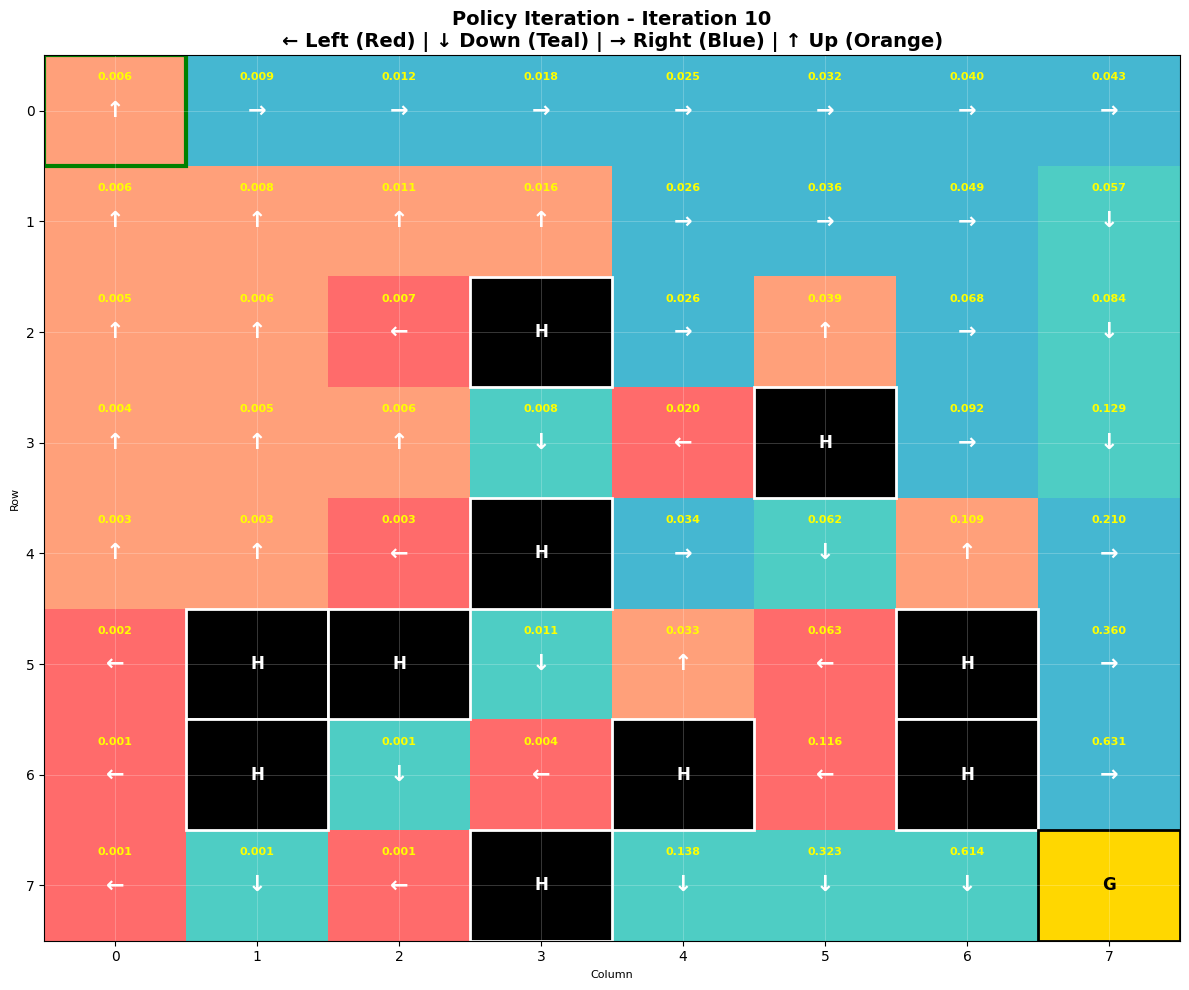


Policy converged after 10 iterations!

Final value function (first 16 states):
[0.00640993 0.00854754 0.01230019 0.01778934 0.02508213 0.0324709
 0.03957135 0.04297846 0.00602313 0.00764457 0.01091135 0.01642643
 0.02605411 0.0361941  0.04935471 0.05730462]

Final policy (first 16 states):
[3 2 2 2 2 2 2 2 3 3 3 3 2 2 2 1]


<Figure size 640x480 with 0 Axes>

In [5]:
import gymnasium as gym
import numpy as np
from IPython.display import display, clear_output
import time

# env = gym.make("FrozenLake-v1",map_name="8x8",render_mode="human")
env = gym.make("FrozenLake-v1", map_name="8x8")
num_states = env.observation_space.n
num_actions = env.action_space.n
V_s = np.zeros(num_states)
pi = np.zeros(num_states, dtype=int)

epsilon = 0.000001  # stopping condition
gamma = 0.9  # discount factor
iteration = 0

# Cache environment dynamics to avoid repeated lookups
P = env.unwrapped.P

# Setup visualization
fig, ax = plt.subplots(figsize=(12, 10))
visualize_policy(env, pi, V_s, iteration=0, ax=ax)
plt.show()

while True:
    # Policy Evaluation: Iteratively update value function until convergence
    while True:
        delta = 0
        for s in range(num_states):
            v_old = V_s[s]
            a = pi[s]  # choose action based on current policy
            env_dynamics = P[s][a]
            
            # Calculate expected value: sum over all possible transitions
            v_new = 0
            for prob, next_state, reward, terminated in env_dynamics:
                # If terminated, next state value is 0 (terminal state)
                next_value = 0 if terminated else V_s[next_state]
                v_new += prob * (reward + gamma * next_value)
            
            V_s[s] = v_new
            delta = max(delta, abs(v_old - V_s[s]))
        
        if delta < epsilon:
            break
    
    # Policy Improvement: Update policy to be greedy w.r.t. current value function
    old_policy = pi.copy()
    
    # Pre-allocate action_values array outside inner loop for better performance
    action_values = np.zeros(num_actions)
    
    for s in range(num_states):
        action_values.fill(0)  # Reset for each state (faster than recreating array)
        
        for a in range(num_actions):
            for prob, next_state, reward, terminated in P[s][a]:
                # If terminated, next state value is 0 (terminal state)
                next_value = 0 if terminated else V_s[next_state]
                action_values[a] += prob * (reward + gamma * next_value)
        
        pi[s] = np.argmax(action_values)
    
    # Check if policy has converged (much faster than looping through all states)
    policy_stable = np.array_equal(old_policy, pi)
    
    iteration += 1
    print(f"Iteration {iteration}: Policy {'stable' if policy_stable else 'changed'}")
    
    # Update visualization
    clear_output(wait=True)
    visualize_policy(env, pi, V_s, iteration=iteration, ax=ax)
    display(fig)
    time.sleep(0.5)  # Small delay to see the changes
    
    if policy_stable:
        print(f"\nPolicy converged after {iteration} iterations!")
        break

print(f"\nFinal value function (first 16 states):\n{V_s[:16]}")
print(f"\nFinal policy (first 16 states):\n{pi[:16]}")



            


## Alternative: Visualize All Iterations Side-by-Side

If you want to see all policy iterations at once, you can use the code below which saves each iteration and displays them in a grid.

Iteration 1: Policy changed
Iteration 2: Policy changed
Iteration 3: Policy changed
Iteration 4: Policy changed
Iteration 5: Policy changed
Iteration 6: Policy changed
Iteration 7: Policy changed
Iteration 8: Policy changed
Iteration 9: Policy changed
Iteration 10: Policy stable
Policy converged after 10 iterations!


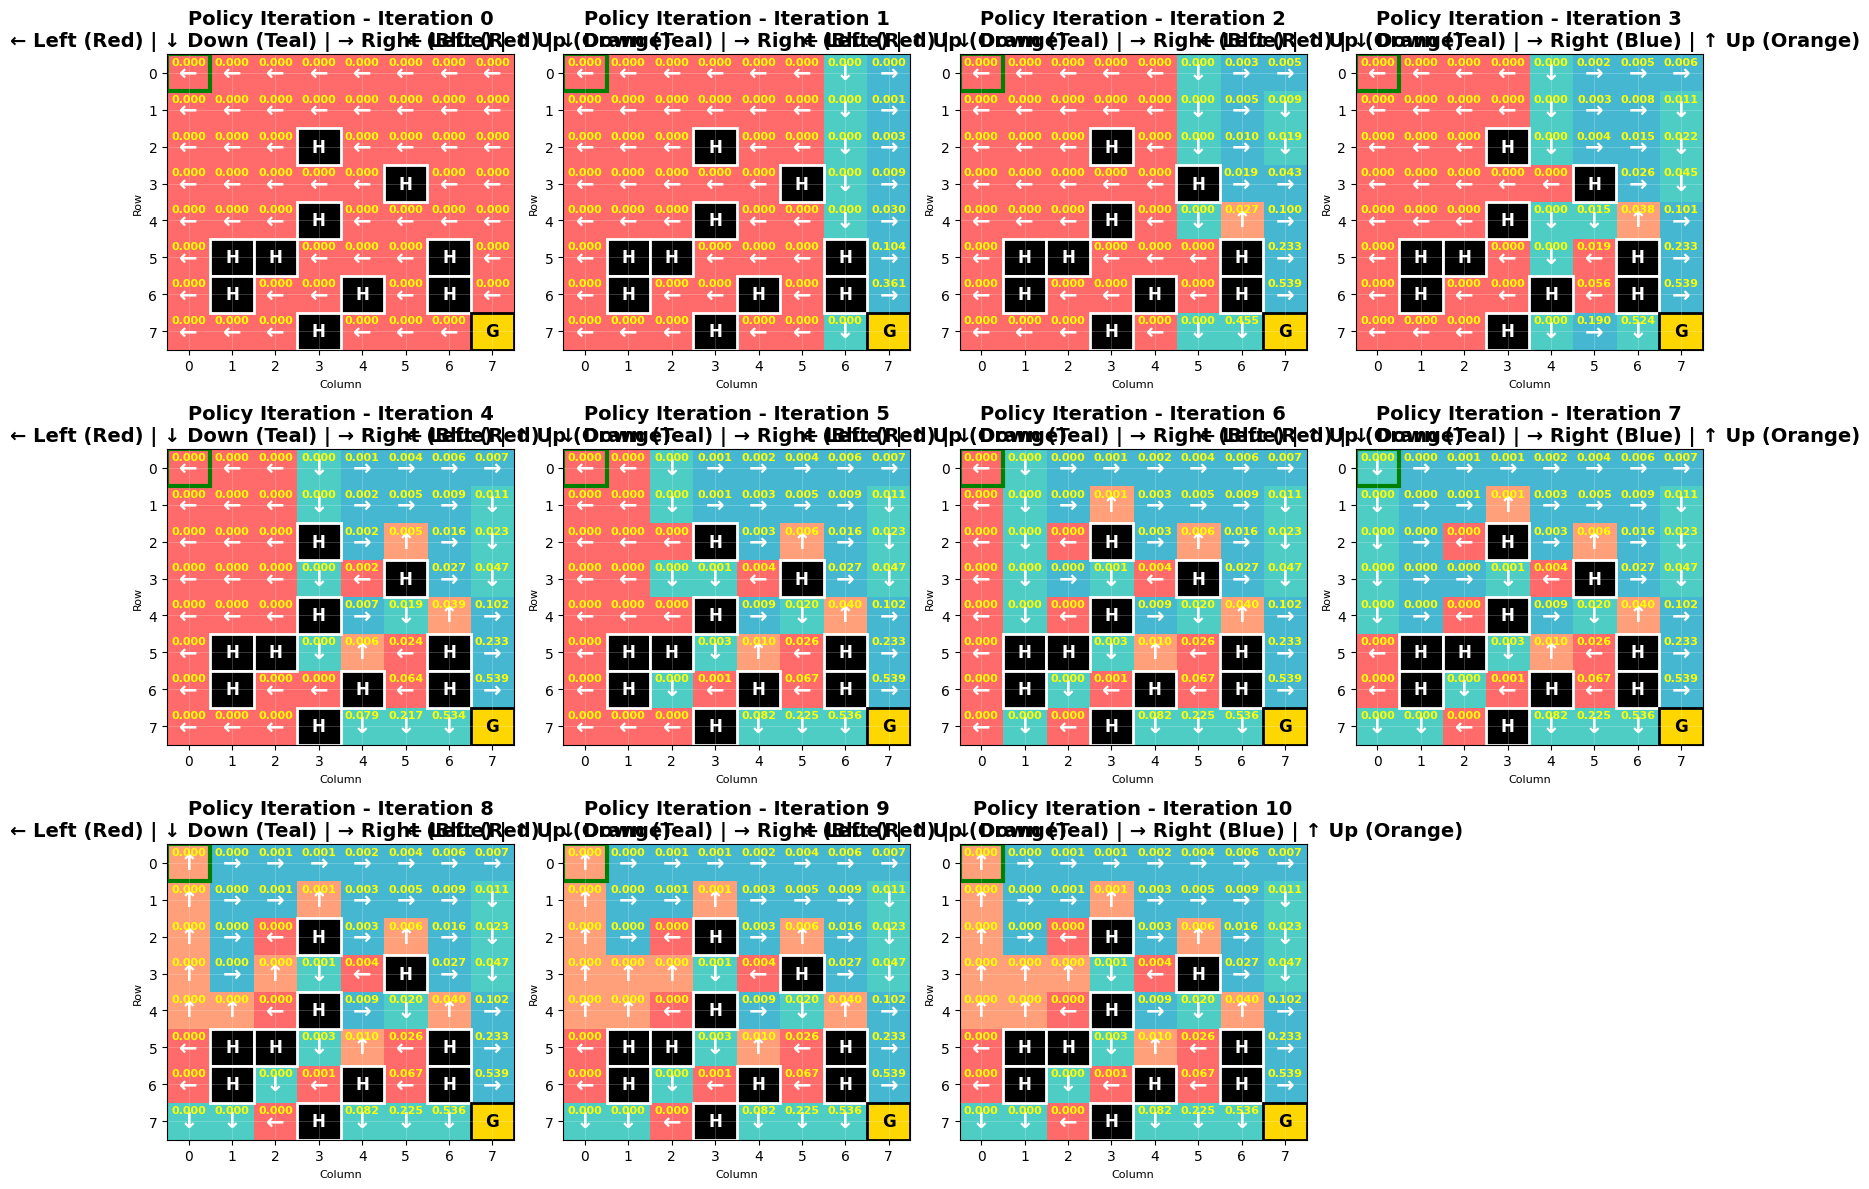


Total iterations: 10
Final value function (first 16 states):
[0.00022324 0.00039109 0.00073562 0.00138024 0.00247306 0.00386416
 0.00554943 0.00654514 0.00020477 0.00034038 0.00064298 0.00132266
 0.00293677 0.00507701 0.0087158  0.011454  ]

Final policy (first 16 states):
[3 2 2 2 2 2 2 2 3 2 2 3 2 2 2 1]


In [6]:
# Alternative implementation: Save policy history and visualize all at once
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("FrozenLake-v1", map_name="8x8")
num_states = env.observation_space.n
num_actions = env.action_space.n
V_s = np.zeros(num_states)
pi = np.zeros(num_states, dtype=int)

epsilon = 0.000001
gamma = 0.8
iteration = 0
P = env.unwrapped.P

# Store policy and value history for visualization
policy_history = [pi.copy()]
value_history = [V_s.copy()]

while True:
    # Policy Evaluation
    while True:
        delta = 0
        for s in range(num_states):
            v_old = V_s[s]
            a = pi[s]
            env_dynamics = P[s][a]
            v_new = 0
            for prob, next_state, reward, terminated in env_dynamics:
                next_value = 0 if terminated else V_s[next_state]
                v_new += prob * (reward + gamma * next_value)
            V_s[s] = v_new
            delta = max(delta, abs(v_old - V_s[s]))
        if delta < epsilon:
            break
    
    # Policy Improvement
    old_policy = pi.copy()
    action_values = np.zeros(num_actions)
    
    for s in range(num_states):
        action_values.fill(0)
        for a in range(num_actions):
            for prob, next_state, reward, terminated in P[s][a]:
                next_value = 0 if terminated else V_s[next_state]
                action_values[a] += prob * (reward + gamma * next_value)
        pi[s] = np.argmax(action_values)
    
    # Save current state
    policy_history.append(pi.copy())
    value_history.append(V_s.copy())
    
    policy_stable = np.array_equal(old_policy, pi)
    iteration += 1
    print(f"Iteration {iteration}: Policy {'stable' if policy_stable else 'changed'}")
    
    if policy_stable:
        print(f"Policy converged after {iteration} iterations!")
        break

# Visualize all iterations in a grid
n_iterations = len(policy_history)
n_cols = min(4, n_iterations)  # Show max 4 columns
n_rows = (n_iterations + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
if n_iterations == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (policy, values) in enumerate(zip(policy_history, value_history)):
    if idx < len(axes):
        visualize_policy(env, policy, values, iteration=idx, ax=axes[idx])

# Hide unused subplots
for idx in range(n_iterations, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\nTotal iterations: {iteration}")
print(f"Final value function (first 16 states):\n{V_s[:16]}")
print(f"\nFinal policy (first 16 states):\n{pi[:16]}")

In [ ]:
env_2 = gym.make("FrozenLake-v1",map_name="8x8", render_mode = "human")
state,_=env_2.reset()
stop = False
while not stop:
    action = pi[state]
    state, reward, terminated, truncated, _ = env_2.step(action)
    env_2.render() # If you used render_mode="human" in gym.make
    stop = terminated or truncated
env_2.close()
# help(env.reset)

<frozen importlib._bootstrap>:491: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
/home/robin/anaconda3/envs/gymnasium/lib/python3.14/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


error: File is not a Windows BMP file

: 